# DỰ ĐOÁN BURNOUT SCORE BẰNG MACHINE LEARNING

**Target:** `burnout_level`

**Bài toán:** Hồi quy Logistic

**Các thuật toán sử dụng:**
- Logistic Regression


1. Đọc và kiểm tra dữ liệu

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

train_df = pd.read_csv(
    "../data/burnout_train_standardized.csv")
test_df = pd.read_csv(
    "../data/burnout_test_standardized.csv")

print("Kích thước Train:", train_df.shape)
print("Kích thước Test:", test_df.shape)


Kích thước Train: (76001, 49)
Kích thước Test: (19001, 49)


In [30]:
drop_cols = ['burnout_level', 'burnout_level_encoded']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['burnout_level']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['burnout_level']

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (76001, 47)
X_test: (19001, 47)


 2. Xây dựng mô hình Logistic Regression

In [31]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
accuracy_log = accuracy_score(y_test, y_pred_log)

print("Accuracy Logistic Regression:", round(accuracy_log, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print(
    train_df[
        ["burnout_level", "burnout_level_encoded"]
    ].drop_duplicates().sort_values("burnout_level_encoded")
)

Accuracy Logistic Regression: 0.7163

Classification Report:
              precision    recall  f1-score   support

        High       0.50      0.61      0.55      3659
         Low       0.83      0.82      0.82      4914
    Moderate       0.64      0.59      0.61      5000
      Severe       0.87      0.81      0.84      5428

    accuracy                           0.72     19001
   macro avg       0.71      0.71      0.71     19001
weighted avg       0.73      0.72      0.72     19001

   burnout_level  burnout_level_encoded
0            Low                      0
8       Moderate                      1
1           High                      2
10        Severe                      3


3. Đánh giá mô hình

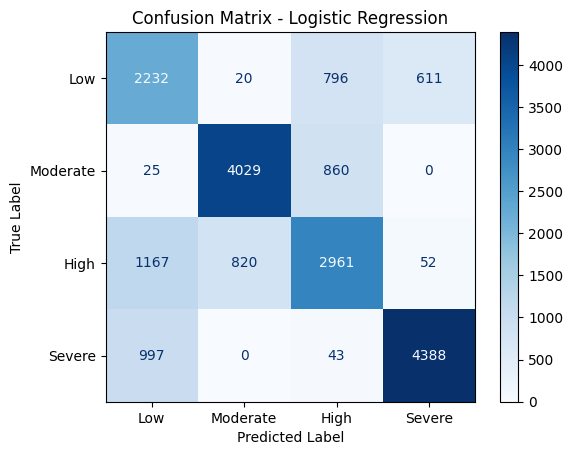

In [32]:
labels = ["Low", "Moderate", "High", "Severe"]

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    display_labels=labels,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

3.2. ROC-AUC

In [33]:
y_proba_log = log_model.predict_proba(X_test)

roc_auc_log = roc_auc_score(
    y_test,
    y_proba_log,
    multi_class="ovr",
    average="weighted"
)
print("ROC-AUC Logistic Regression:", round(roc_auc_log, 4))
precision_log = precision_score(
    y_test, y_pred_log, average="weighted"
)
recall_log = recall_score(
    y_test, y_pred_log, average="weighted"
)
f1_log = f1_score(
    y_test, y_pred_log, average="weighted"
)
results = pd.DataFrame({
    "Chỉ số": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Giá trị": [
        accuracy_log,
        precision_log,
        recall_log,
        f1_log,
        roc_auc_log
    ]
})
results["Giá trị"] = results["Giá trị"].round(4)
display(results)

ROC-AUC Logistic Regression: 0.9197


,Chỉ số,Giá trị
0,Accuracy,0.7163
1,Precision,0.7266
2,Recall,0.7163
3,F1-Score,0.7200
4,ROC-AUC,0.9197


3.3. kiểm tra overfitting

In [34]:
# Accuracy trên tập Train
train_accuracy = log_model.score(X_train, y_train)

# Accuracy trên tập Test
test_accuracy = log_model.score(X_test, y_test)

print("Train Accuracy:", round(train_accuracy, 4))
print("Test Accuracy :", round(test_accuracy, 4))
print("Chênh lệch    :", round(train_accuracy - test_accuracy, 4))

Train Accuracy: 0.7162
Test Accuracy : 0.7163
Chênh lệch    : -0.0001


4. Dự đoán mức độ Burnout

In [35]:
preprocessor = joblib.load("burnout_preprocessor.joblib")

In [38]:
new_person = pd.DataFrame([{
    "age": 20,
    "gender": "Female",
    "survey_year": 2026,
    "country": 'Vietnam',
    "job_role": "Data Analyst",
    "seniority_level": "Junior",
    "years_experience": 2,
    "work_mode": "Hybrid",
    "salary_usd": 50000,
    "work_hours_per_week": 15,
    "sleep_hours_per_night": 6.5,
    "uses_therapy": 0,
    "ai_tools_daily": 1,
    "deadline_pressure_score": 5,
    "stress_score": 5,
    "phq9_score": 8,
    "gad7_score": 9,
    "seeks_mental_health_support": 0,
    "job_change_intention": 1
}])
display(new_person)


,age,gender,survey_year,country,job_role,seniority_level,years_experience,work_mode,salary_usd,work_hours_per_week,sleep_hours_per_night,uses_therapy,ai_tools_daily,deadline_pressure_score,stress_score,phq9_score,gad7_score,seeks_mental_health_support,job_change_intention
0,20,Female,2026,Vietnam,Data Analyst,Junior,2,Hybrid,50000,15,6.5,0,1,5,5,8,9,0,1


In [39]:
# Tiền xử lý thông tin người mới
new_person_processed = pd.DataFrame(
    preprocessor.transform(new_person),
    columns=preprocessor.get_feature_names_out()
)
prediction = log_model.predict(new_person_processed)

predicted_level = prediction[0]

print("Mức độ Burnout dự đoán:", predicted_level)

Mức độ Burnout dự đoán: Low
